# Notebook 05: XGBoost Challenger Model

## 01. Notebook Purpose

This notebook evaluates XGBoost as a challenger model to the tuned Random Forest developed in the previous notebook. The goal is to determine whether XGBoost can achieve stronger predictive performance on the machine failure classification task while preserving a disciplined and comparable modeling workflow.

To ensure a fair comparison, this notebook uses the same prepared training and test datasets created earlier, as well as the same evaluation logic used in previous modeling steps. Particular attention is given to Average Precision because the target is imbalanced and detecting failure cases is especially important in the predictive maintenance context.

The notebook follows a focused modeling strategy. Instead of introducing many new algorithms at once, it tests one strong challenger model, tunes it systematically, and compares its final performance against the tuned Random Forest. This keeps the project progression transparent, recruiter-friendly, and methodologically consistent.

## 02. Imports and Loading Data

In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#loading datasets
X_train = pd.read_csv("../data/processed/X_train_prepared.csv")
X_test = pd.read_csv("../data/processed/X_test_prepared.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

In [11]:
X_train.columns = (
    X_train.columns
    .str.replace("[", "(", regex=False)
    .str.replace("]", ")", regex=False)
    .str.replace("<", "lt_", regex=False)
)

X_test.columns = (
    X_test.columns
    .str.replace("[", "(", regex=False)
    .str.replace("]", ")", regex=False)
    .str.replace("<", "lt_", regex=False)
)

This step cleans the feature names so they are compatible with XGBoost. Some original column names contain characters such as square brackets, which XGBoost does not accept in feature names. The renaming does not change the data itself; it only makes the column labels safe for model training and evaluation.

In [12]:
print(X_train.columns.tolist())

['num__Air temperature (K)', 'num__Process temperature (K)', 'num__Rotational speed (rpm)', 'num__Torque (Nm)', 'num__Tool wear (min)', 'num__Temperature difference (K)', 'num__ToolWear_x_Torque', 'cat__Type_H', 'cat__Type_L', 'cat__Type_M']


In [4]:
#verfying
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)


## Define the XGBoost Evaluation Strategy

In [13]:
negative_class_count = (y_train == 0).sum()
positive_class_count = (y_train == 1).sum()

scale_pos_weight = negative_class_count / positive_class_count

print("Negative class count:", negative_class_count)
print("Positive class count:", positive_class_count)
print("scale_pos_weight:", round(scale_pos_weight, 4))

Negative class count: 7729
Positive class count: 271
scale_pos_weight: 28.5203


This code calculates the ratio between the majority class and the minority class in the training data. For XGBoost, this ratio can be passed through the `scale_pos_weight` parameter so that the model gives more importance to failure cases during training. This is a common and appropriate way to address imbalance in binary classification problems when using gradient boosting.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

## 04. Train and Evaluate a Baseline XGBoost Model

In [15]:
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

This code defines a baseline XGBoost classifier using a standard binary classification objective. The model is kept relatively simple at this stage because the goal is first to establish a baseline performance level before hyperparameter tuning. The `scale_pos_weight` parameter is included so that the model accounts for the imbalance between non-failure and failure cases.

In [16]:
xgb_baseline_cv = cross_validate(
    estimator=xgb_baseline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

This evaluates the baseline XGBoost model using stratified cross-validation. The purpose is to estimate how well the untuned challenger model performs across different splits of the training data before investing in hyperparameter tuning. This also creates a more transparent modeling progression, since the notebook does not jump directly from model selection to tuning without first checking a baseline.

In [17]:
baseline_cv_results = pd.DataFrame(xgb_baseline_cv).mean().round(4)
baseline_cv_results

fit_time                  0.1542
score_time                0.0264
test_accuracy             0.9852
test_precision            0.8021
test_recall               0.7528
test_f1                   0.7763
test_roc_auc              0.9704
test_average_precision    0.8313
dtype: float64

The baseline XGBoost model already delivers strong results, suggesting that it is a credible challenger to the tuned Random Forest. Its ROC-AUC and Average Precision indicate good ranking performance despite the class imbalance, while the F1-score shows a reasonably balanced classification behavior. However, recall still leaves room for improvement, which is important in a predictive maintenance setting where missed failures are costly. Overall, these results justify proceeding with hyperparameter tuning to assess whether XGBoost can improve further and become a stronger final candidate.

## 05. Hyperparameter Tuning for XGBoost

In [18]:
# Hyperparameters definition
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

In [19]:
xgb_tuned_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ),
    param_distributions=param_distributions,
    n_iter=25,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

This code sets up the randomized hyperparameter search for XGBoost. RandomizedSearchCV is used because it allows efficient exploration of multiple parameter combinations without requiring an exhaustive search. The optimization target is Average Precision, which is appropriate for this imbalanced classification problem because it focuses on the trade-off between precision and recall across thresholds.

In [20]:
xgb_tuned_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,25
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
#Find the best parameters
print("Best Average Precision (CV):", round(xgb_tuned_search.best_score_, 4))
print("Best parameters:")
xgb_tuned_search.best_params_

Best Average Precision (CV): 0.8539
Best parameters:


{'subsample': 0.7,
 'n_estimators': 100,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.1,
 'gamma': 0.1,
 'colsample_bytree': 1.0}

## 06. Evaluation on the Test Set

In [23]:
xgb_tuned = xgb_tuned_search.best_estimator_

y_pred_xgb = xgb_tuned.predict(X_test)
y_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]

xgb_test_results = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1-score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_proba_xgb),
    "Average Precision": average_precision_score(y_test, y_proba_xgb)
}

pd.Series(xgb_test_results).round(4)

Accuracy             0.9845
Precision            0.7403
Recall               0.8382
F1-score             0.7862
ROC-AUC              0.9811
Average Precision    0.8771
dtype: float64

The tuned XGBoost model is evaluated on the hold-out test set using the same metrics that were used for the Random Forest models. This step measures how well the tuned challenger generalizes to unseen data and provides the basis for the final model comparison. Using the same test metrics ensures that the comparison remains fair and methodologically consistent.

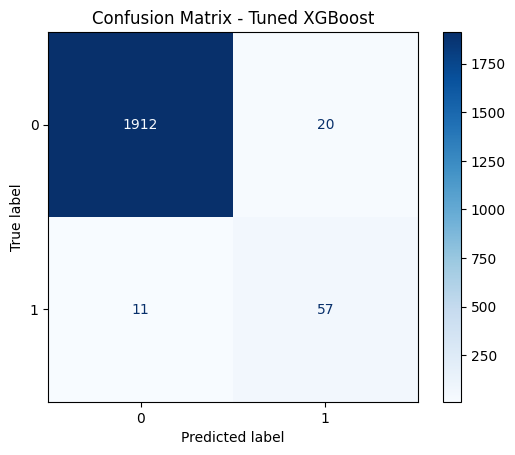

In [24]:
#display confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

The confusion matrix indicates that the tuned XGBoost model performs well on unseen data. Most non-failure cases are classified correctly, and the model also detects a substantial share of true failure cases. Only 11 actual failures are missed, while 20 non-failure cases are incorrectly flagged as failures.

From a predictive maintenance perspective, this is a promising result because the model captures most failure events while keeping false alarms at a manageable level. This suggests a useful trade-off between recall and precision, which is especially important in an imbalanced classification problem where missed failures matter more than accuracy alone.

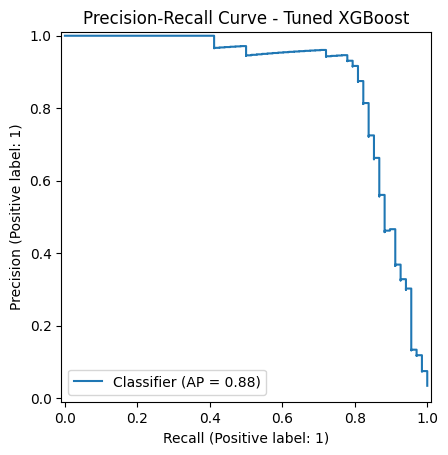

In [25]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb)
plt.title("Precision-Recall Curve - Tuned XGBoost")
plt.show()

The precision-recall curve indicates that the tuned XGBoost model performs strongly on the minority failure class. Precision remains high over a large part of the curve, showing that many predicted failures are correct even as recall increases. The Average Precision of 0.88 supports this and suggests that the model separates failure and non-failure cases effectively.

As expected, precision falls more sharply when recall becomes very high, meaning that detecting nearly all failures would require accepting more false alarms. Overall, the curve shows a strong and practically useful trade-off between recall and precision, which is especially important in this imbalanced predictive maintenance problem.

## 07. Compare Tuned XGBoost with Tuned Random Forest

In [26]:
rf_test_results = {
    "Accuracy": 0.9910,
    "Precision": 0.8906,
    "Recall": 0.8382,
    "F1-score": 0.8636,
    "ROC-AUC": 0.9688,
    "Average Precision": 0.8761
}

comparison_df = pd.DataFrame({
    "Tuned Random Forest": rf_test_results,
    "Tuned XGBoost": xgb_test_results
}).round(4)

comparison_df

,Tuned Random Forest,Tuned XGBoost
Accuracy,0.9910,0.9845
Precision,0.8906,0.7403
Recall,0.8382,0.8382
F1-score,0.8636,0.7862
ROC-AUC,0.9688,0.9811
Average Precision,0.8761,0.8771


The comparison indicates that the tuned Random Forest remains the stronger final model candidate. While tuned XGBoost slightly improves ROC-AUC and Average Precision, it underperforms on precision, F1-score, and accuracy, while recall remains the same. This means that XGBoost does not improve failure detection, but instead produces more false-positive predictions.

For this reason, the tuned Random Forest continues to offer the better balance between identifying real failures and limiting unnecessary false alarms. At this stage, it remains the preferred model for the machine failure classification task.

In [28]:
rf_cm_values = {
    "True Negatives": 1925,
    "False Positives": 7,
    "False Negatives": 11,
    "True Positives": 57
}

xgb_tn, xgb_fp, xgb_fn, xgb_tp = cm_xgb.ravel()

xgb_cm_values = {
    "True Negatives": xgb_tn,
    "False Positives": xgb_fp,
    "False Negatives": xgb_fn,
    "True Positives": xgb_tp
}

cm_comparison_df = pd.DataFrame({
    "Tuned Random Forest": rf_cm_values,
    "Tuned XGBoost": xgb_cm_values
})

cm_comparison_df["Difference (XGBoost - RF)"] = (
    cm_comparison_df["Tuned XGBoost"] - cm_comparison_df["Tuned Random Forest"]
)

cm_comparison_df

,Tuned Random Forest,Tuned XGBoost,Difference (XGBoost - RF)
True Negatives,1925,1912,-13
False Positives,7,20,13
False Negatives,11,11,0
True Positives,57,57,0


## 08. Conclusion

This notebook evaluated XGBoost as a challenger model to the tuned Random Forest selected in the previous step of the project. After training a baseline XGBoost model, performing hyperparameter tuning, and evaluating the tuned model on the hold-out test set, the final comparison showed that XGBoost did not surpass the tuned Random Forest as the strongest overall candidate.

Although tuned XGBoost achieved slightly higher ROC-AUC and Average Precision, it did not improve recall and produced substantially lower precision, which led to a weaker F1-score overall. This means that, at the current decision threshold, XGBoost introduces more false-positive predictions without improving failure detection.

Overall, the tuned Random Forest remains the preferred model for the machine failure classification task. The project has now progressed from baseline model selection to model improvement and challenger evaluation in a structured and transparent way, providing a strong foundation for the next step of the workflow.